### Import Modules

In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

### Load Cluster Data

In [2]:
data = pd.read_csv("../data/raw/repos/embeddings_call_graph_clusters.csv")
data['code_file'] = data['cluster_file'].apply(lambda x: x.replace('./result/repo_callgraph_clusters/', ''))
# data = pd.read_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/notebooks/embeddings_result/embeddings_call_graph_clusters_v2.csv")
# data['code_file'] = data['code_file'].apply(lambda x: x.replace('/root/AI-Pattern-Mining-Project/outputs/prompt & rag/20251028_085918 - Run/generated_code/', ''))

In [3]:
le = joblib.load('./models/label_encoder_v2.joblib')
pipeline = joblib.load('./models/svc_classification_pipeline_v2.joblib')

In [4]:
feature_cols = [col for col in data.columns if col not in ['cluster_file', 'code_file', 'cluster_label']]
features = data[feature_cols]

In [5]:
predictions = pipeline.predict(features)
predicted_labels = le.inverse_transform(predictions)

In [7]:
predictions = pipeline.predict_poraba(features)
predicted_labels = le.inverse_transform(predictions)

AttributeError: 'Pipeline' object has no attribute 'predict_poraba'

In [65]:
prediction_df = pd.DataFrame(predicted_labels, columns=['Predicted Cluster Label'])
prediction_df['code_file'] = data['code_file']

In [ ]:
prediction_df.head()

,Predicted Cluster Label,code_file
0,Explainable AI (XAI) Techniques,3DOD_thesis/cluster_0.py
1,Explainable AI (XAI) Techniques,3DOD_thesis/cluster_1.py
2,Explainable AI (XAI) Techniques,3DOD_thesis/cluster_10.py
3,Retrieval Augmented Generation(RAG) Optimizati...,3DOD_thesis/cluster_2.py
4,LLM Code Execution for Precision,3DOD_thesis/cluster_3.py


In [68]:
prediction_df.to_csv('./predictions/predicted_clusters_v2.csv', index=False)

### Analysis

In [61]:
count_df = pd.DataFrame(predicted_labels, columns=['Predicted Cluster Label'])
count_df = count_df['Predicted Cluster Label'].value_counts().reset_index()
count_df.columns = ['Cluster Label', 'Count']

In [63]:
count_df

,Cluster Label,Count
0,Explainable AI (XAI) Techniques,555
1,LLM KV Cache Optimization,322
2,LLM Code Execution for Precision,263
3,LLM Agent Training & Alignment,250
4,Integrating Knlowladge Graph,205
5,Reranking,107
6,Tool Use,104
7,Enhanced User Intent Comprehension,100
8,Multimodal Reasoning Extensions,81
9,Retrieval Augmented Generation(RAG) Optimizati...,80


### Visualize predictions

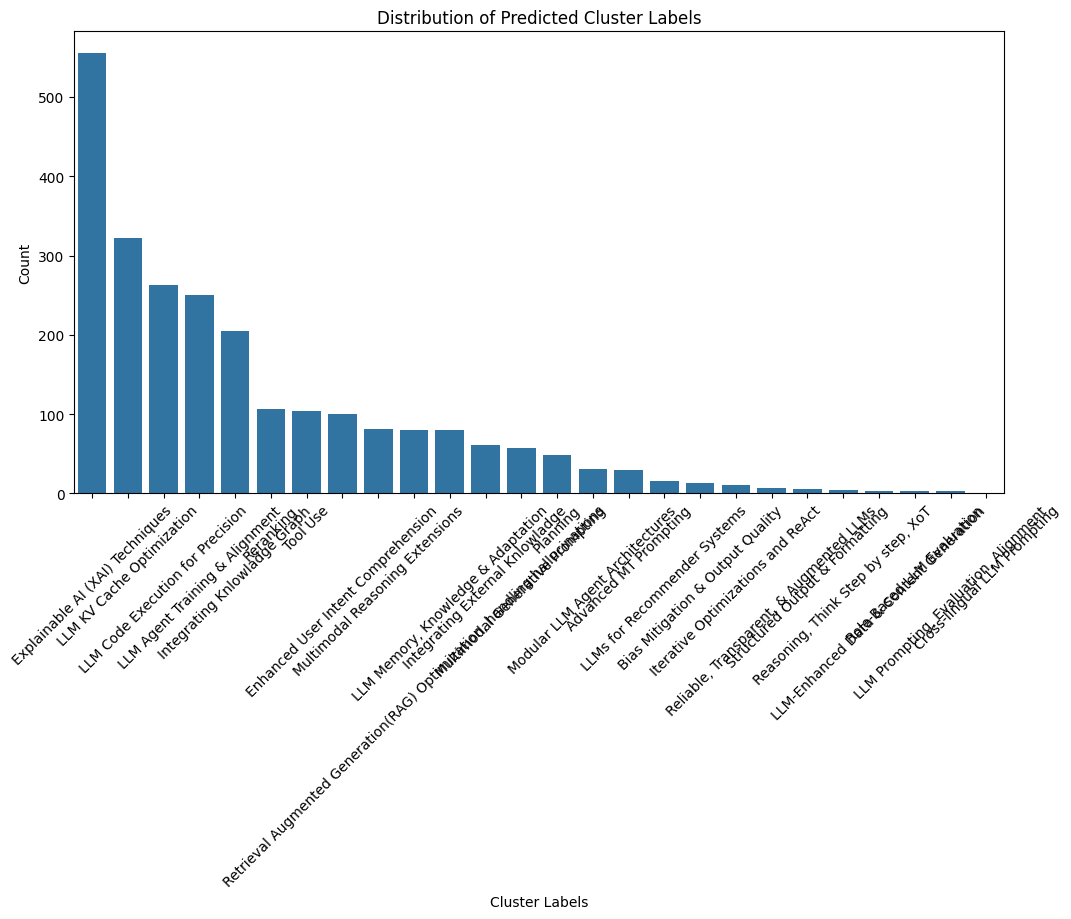

In [60]:
### Visualize the results
plt.figure(figsize=(12,6))
sns.countplot(x=predicted_labels, order=pd.Series(predicted_labels).value_counts().index)
plt.title('Distribution of Predicted Cluster Labels')
plt.xlabel('Cluster Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()